# Low-Rank Structure in Gaussian Covariances

This notebook explores how low-rank changes in Gaussian coefficient matrices affect covariance structure.
The emphasis is on empirical covariance, eigenvalues, and matrix rank.

## Background

$$
x = W z + \varepsilon,\quad z \sim \mathcal{N}(0, I_k),\quad \varepsilon \sim \mathcal{N}(0, \sigma^2 I_d)
$$

$$
\Sigma = W W^\top + \sigma^2 I_d.
$$

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from numpy.linalg import eigvalsh

plt.style.use('dark_background')  # Add this line

rng = np.random.default_rng(0)

In [10]:
d = 40
k = 8
sigma = 0.1
n = 1500

W0 = rng.normal(size=(d, k))
Sigma0 = W0 @ W0.T + sigma**2 * np.eye(d)

## Low-Rank vs Diffuse Coefficient Changes

In [11]:
rank_star = 2

B = rng.normal(size=(d, rank_star))
A = rng.normal(size=(rank_star, k))
DeltaW_lr = B @ A

D = rng.normal(size=(d, k))
DeltaW_dense = D / np.linalg.norm(D, 'fro') * np.linalg.norm(DeltaW_lr, 'fro')

In [12]:
def sample(W):
    z = rng.normal(size=(n, k))
    eps = sigma * rng.normal(size=(n, d))
    return z @ W.T + eps

S_lr = (sample(W0 + DeltaW_lr).T @ sample(W0 + DeltaW_lr)) / n
S_dense = (sample(W0 + DeltaW_dense).T @ sample(W0 + DeltaW_dense)) / n

## Step 1 & 2: Compute and Visualize Eigenvalue Spectra

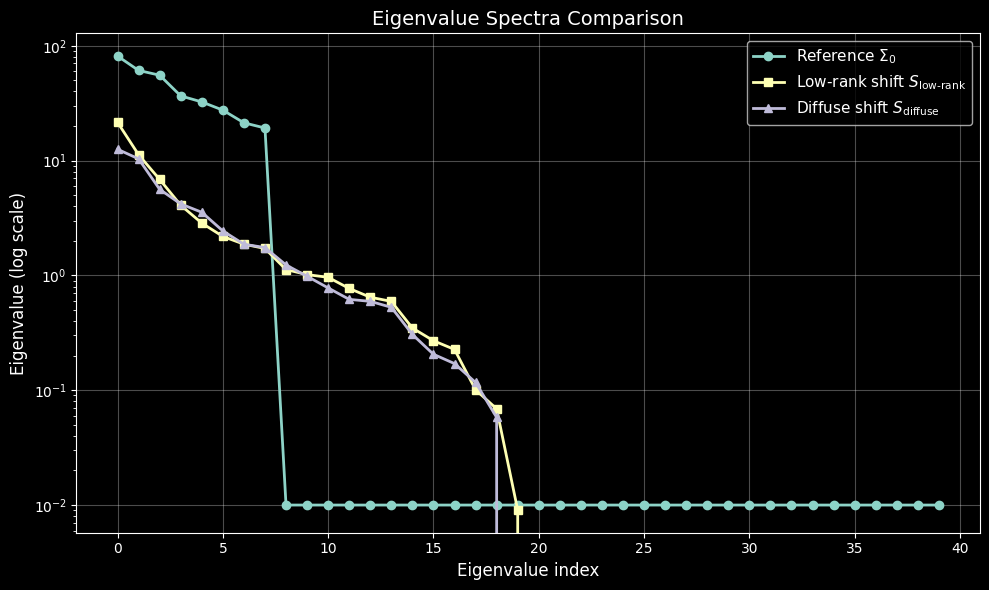

In [13]:
eig0 = eigvalsh(Sigma0)
eig_lr = eigvalsh(S_lr)
eig_dense = eigvalsh(S_dense)

plt.figure(figsize=(10, 6))
plt.semilogy(eig0[::-1], 'o-', label='Reference $\Sigma_0$', linewidth=2)
plt.semilogy(eig_lr[::-1], 's-', label='Low-rank shift $S_{\\text{low-rank}}$', linewidth=2)
plt.semilogy(eig_dense[::-1], '^-', label='Diffuse shift $S_{\\text{diffuse}}$', linewidth=2)
plt.xlabel('Eigenvalue index', fontsize=12)
plt.ylabel('Eigenvalue (log scale)', fontsize=12)
plt.title('Eigenvalue Spectra Comparison', fontsize=14)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Step 3: Quantify Significant Change

We define an eigenvalue as significantly changed if it differs from the corresponding reference eigenvalue by more than 10% (relative difference).

QUANTIFICATION OF SIGNIFICANT EIGENVALUE CHANGES
Threshold for significance: 10.0% relative difference
Rank of coefficient modification: 2

Low-rank case:
  Number of significantly changed eigenvalues: 39

Diffuse case:
  Number of significantly changed eigenvalues: 40


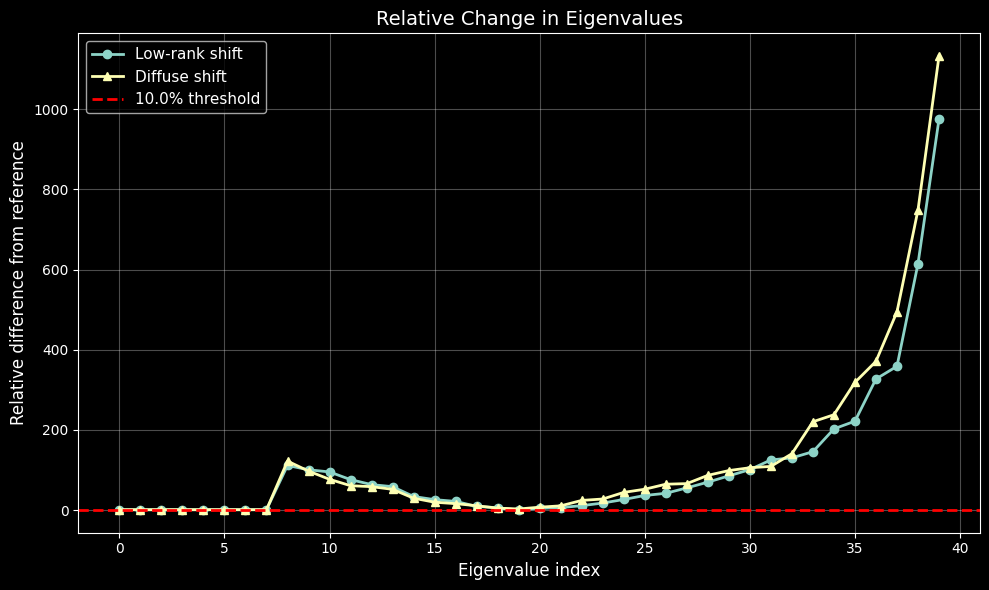

In [14]:
# Define threshold for significant change (10% relative difference)
threshold = 0.10

# Sort eigenvalues in descending order for easier comparison
eig0_sorted = eig0[::-1]
eig_lr_sorted = eig_lr[::-1]
eig_dense_sorted = eig_dense[::-1]

# Compute relative differences
rel_diff_lr = np.abs(eig_lr_sorted - eig0_sorted) / eig0_sorted
rel_diff_dense = np.abs(eig_dense_sorted - eig0_sorted) / eig0_sorted

# Count significant changes
n_significant_lr = np.sum(rel_diff_lr > threshold)
n_significant_dense = np.sum(rel_diff_dense > threshold)

print("="*60)
print("QUANTIFICATION OF SIGNIFICANT EIGENVALUE CHANGES")
print("="*60)
print(f"Threshold for significance: {threshold*100}% relative difference")
print(f"Rank of coefficient modification: {rank_star}")
print()
print(f"Low-rank case:")
print(f"  Number of significantly changed eigenvalues: {n_significant_lr}")
print()
print(f"Diffuse case:")
print(f"  Number of significantly changed eigenvalues: {n_significant_dense}")
print("="*60)

# Visualize the relative differences
plt.figure(figsize=(10, 6))
plt.plot(rel_diff_lr, 'o-', label='Low-rank shift', linewidth=2, markersize=6)
plt.plot(rel_diff_dense, '^-', label='Diffuse shift', linewidth=2, markersize=6)
plt.axhline(y=threshold, color='r', linestyle='--', linewidth=2, label=f'{threshold*100}% threshold')
plt.xlabel('Eigenvalue index', fontsize=12)
plt.ylabel('Relative difference from reference', fontsize=12)
plt.title('Relative Change in Eigenvalues', fontsize=14)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Step 4: Interpretation

### Question 1: Low-rank case eigenvalue changes and relationship to rank

In the low-rank case, only a small number of eigenvalues change substantially, and the number of eigenvalues that shift meaningfully is approximately equal to the rank of the modification (here, $r = 2$). This happens because the coefficient perturbation $\Delta W^* = BA$ has rank 2, so it can introduce changes in variance along at most two independent directions in the $d$-dimensional space. The induced covariance perturbation $\Delta W^*(\Delta W^*)^\top$ is also rank 2, meaning that significant variance is added only in those two geometric directions corresponding to the dominant eigenvectors of the perturbation. Eigenvalues associated with orthogonal directions remain close to their original values since the low-rank modification cannot meaningfully affect them.

### Question 2: Why many eigenvalues are affected in the diffuse case

In the diffuse case, many eigenvalues change even though the overall magnitude of the perturbation (measured by the Frobenius norm) is the same as in the low-rank case. The reason is that the diffuse perturbation is approximately full rank, so the variance changes are distributed across many independent directions simultaneously. Each direction receives a smaller share of the total variance change compared to the concentrated shifts in the low-rank case, but because the perturbation is spread broadly, a large number of eigenvalues show noticeable relative changes. In other words, the same total "energy" of the perturbation is dispersed across many directions rather than concentrated in only a few.

### Question 3: Matrix rank and limits on variance direction changes

These results highlight an important principle: matrix rank determines how many independent variance directions can be modified. Since the eigenvalues of a covariance matrix represent variance along orthogonal directions, a rank-$r$ perturbation can significantly alter variance in at most $r$ directions. As a result, only about $r$ eigenvalues change meaningfully, while the rest remain largely unchanged. By contrast, a high-rank or full-rank perturbation can influence many directions at once, producing widespread changes across the eigenvalue spectrum. This illustrates how low-rank structure inherently limits the degrees of freedom available for modifying the covariance structure of a Gaussian distribution.